# PP-OCRv5 через официальный PaddleOCR

## установка PaddleOCR

In [ ]:
!python -m pip install -U pip
!python -m pip install numpy==1.26.4 pandas==2.2.2
!python -m pip install paddlepaddle-gpu
!git clone https://github.com/PaddlePaddle/PaddleOCR
%cd PaddleOCR
!python -m pip install -r requirements.txt
%cd /content

## импорты

In [ ]:

from __future__ import annotations
from pathlib import Path
import json
import random
import re
import shutil
import subprocess
import time
from typing import List, Dict
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
try:
    from google.colab import drive
    if not Path('/content/drive').exists():
        drive.mount('/content/drive')
except Exception:
    pass

## пути

In [ ]:
PROJECT_ROOT = Path('/content')
OCR_ROOT = Path('/content/drive/MyDrive/ocr_dataset')
PADDLEOCR_REPO = PROJECT_ROOT / 'PaddleOCR'

LABEL_DIR = OCR_ROOT / 'paddleocr'
TRAIN_LABEL = LABEL_DIR / 'rec_gt_train.txt'
VALID_LABEL = LABEL_DIR / 'rec_gt_valid.txt'
TEST_LABEL = LABEL_DIR / 'rec_gt_test.txt'

WORK_DIR = PROJECT_ROOT / 'ppocrv5_official_run'
WORK_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = WORK_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_DIR = WORK_DIR / 'configs'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

INFER_DIR = WORK_DIR / 'inference_outputs'
INFER_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_WITH_NORMALIZED_TEXT = True
TEXT_FIELD = 'text_norm' if TRAIN_WITH_NORMALIZED_TEXT else 'text_raw'

print("OCR_ROOT:", OCR_ROOT)
print("PADDLEOCR_REPO:", PADDLEOCR_REPO)
print("WORK_DIR:", WORK_DIR)

## нормализация и подготовка датасета

In [4]:
SIMILAR_MAP = str.maketrans({
    'А': 'A', 'В': 'B', 'С': 'C', 'Е': 'E', 'Н': 'H',
    'К': 'K', 'М': 'M', 'О': 'O', 'Р': 'P', 'Т': 'T',
    'Х': 'X', 'У': 'Y',
    'а': 'A', 'в': 'B', 'с': 'C', 'е': 'E', 'н': 'H',
    'к': 'K', 'м': 'M', 'о': 'O', 'р': 'P', 'т': 'T',
    'х': 'X', 'у': 'Y',
})

def normalize_plate_text(text: str) -> str:
    return text.strip().upper().translate(SIMILAR_MAP)

def contains_cyrillic(text: str) -> bool:
    return bool(re.search(r'[А-Яа-яЁё]', text))

def contains_latin(text: str) -> bool:
    return bool(re.search(r'[A-Za-z]', text))

def mixed_script(text: str) -> bool:
    return contains_cyrillic(text) and contains_latin(text)

def read_rec_labels(path: Path) -> List[Dict]:
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        rel_path, text = line.split('\t', 1)
        text = text.strip()
        rows.append({
            'rel_path': rel_path,
            'image_path': str(OCR_ROOT / rel_path),
            'text_raw': text,
            'text_norm': normalize_plate_text(text),
            'is_mixed_script': mixed_script(text),
        })
    return rows

train rows= 203 min_len= 2 max_len= 21 mixed_script= 0
valid rows= 63 min_len= 2 max_len= 11 mixed_script= 1
test rows= 29 min_len= 3 max_len= 10 mixed_script= 0


In [ ]:
splits = {
    'train': read_rec_labels(TRAIN_LABEL),
    'valid': read_rec_labels(VALID_LABEL),
    'test': read_rec_labels(TEST_LABEL),
}

for split_name, rows in splits.items():
    lens = [len(r['text_raw']) for r in rows]
    print(
        split_name,
        "rows=", len(rows),
        "min_len=", min(lens) if lens else 0,
        "max_len=", max(lens) if lens else 0,
        "mixed_script=", sum(r['is_mixed_script'] for r in rows),
    )

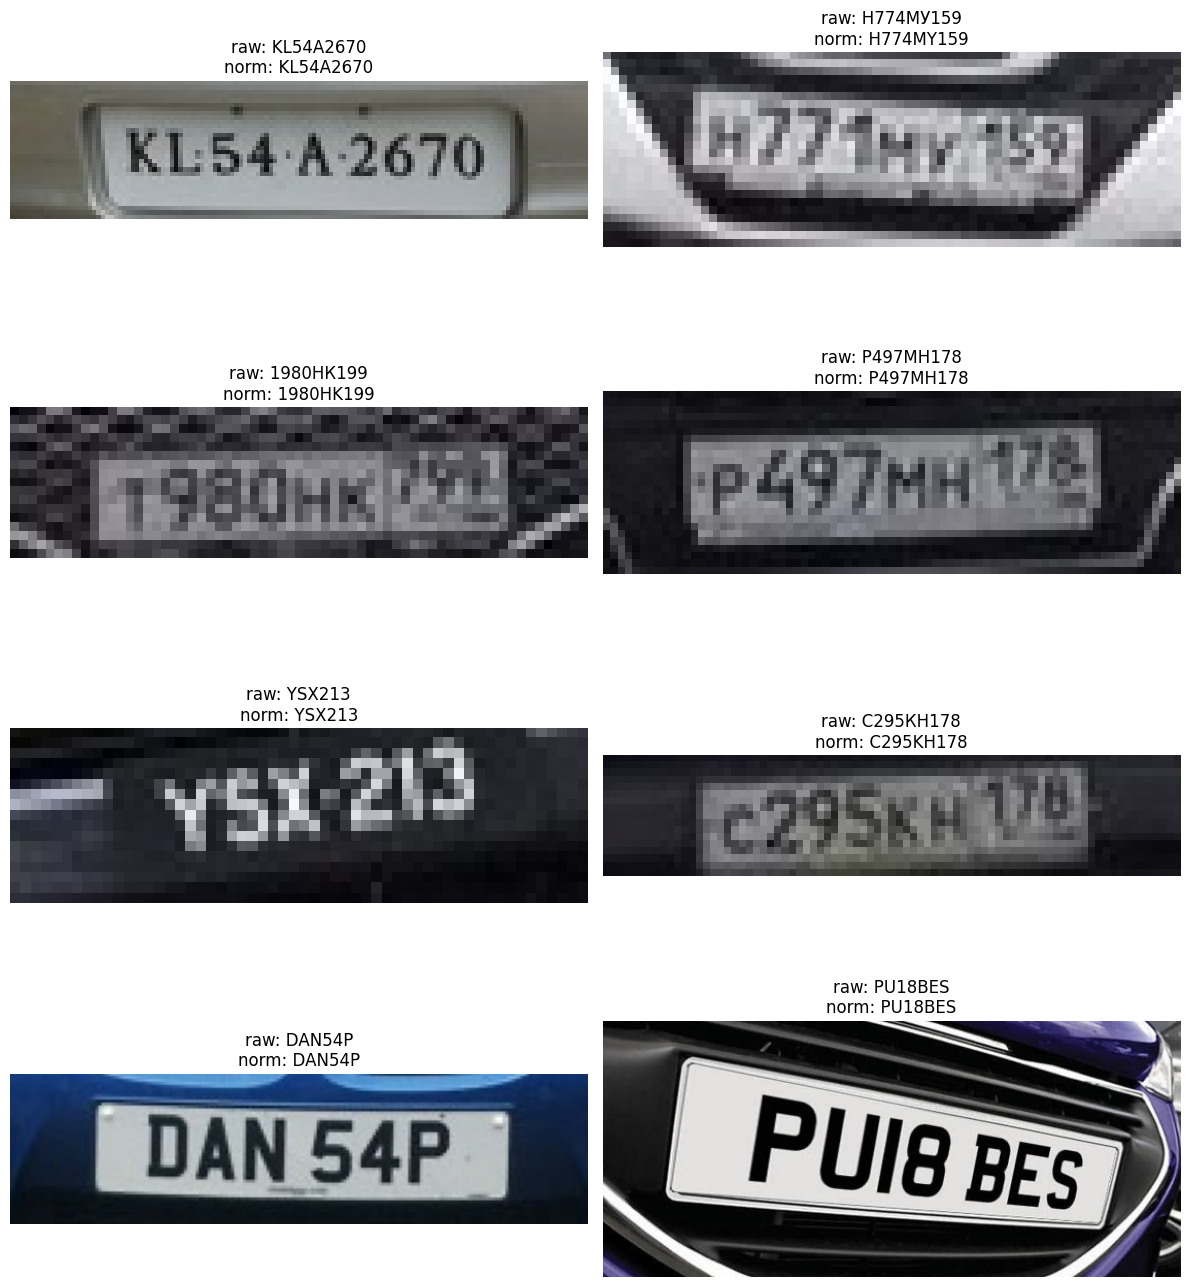

In [5]:

sample_rows = random.sample(splits['train'], k=min(8, len(splits['train'])))
cols = 2
rows_n = (len(sample_rows) + cols - 1) // cols

plt.figure(figsize=(12, max(3, rows_n * 3.5)))
for i, row in enumerate(sample_rows, start=1):
    img = Image.open(row['image_path']).convert('RGB')
    plt.subplot(rows_n, cols, i)
    plt.imshow(img)
    plt.title(f"raw: {row['text_raw']}\nnorm: {row['text_norm']}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
def collect_charset(rows: List[Dict], text_field: str = TEXT_FIELD) -> List[str]:
    chars = sorted({ch for row in rows for ch in row[text_field]})
    return chars

chars: 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ
dict path: /content/ppocrv5_official_run/data/plate_dict.txt
num chars: 36


In [ ]:
charset = collect_charset(splits['train'] + splits['valid'] + splits['test'])
DICT_PATH = DATA_DIR / 'plate_dict.txt'
DICT_PATH.write_text('\n'.join(charset), encoding='utf-8')

print("chars:", ''.join(charset))
print("dict path:", DICT_PATH)
print("num chars:", len(charset))

In [ ]:
def write_ppocr_label(rows: List[Dict], out_path: Path, text_field: str = TEXT_FIELD):
    with out_path.open('w', encoding='utf-8') as f:
        for row in rows:
            f.write(f"{row['image_path']}\t{row[text_field]}\n")

TRAIN_TXT = DATA_DIR / 'train.txt'
VALID_TXT = DATA_DIR / 'val.txt'
TEST_TXT = DATA_DIR / 'test.txt'

write_ppocr_label(splits['train'], TRAIN_TXT)
write_ppocr_label(splits['valid'], VALID_TXT)
write_ppocr_label(splits['test'], TEST_TXT)

print(TRAIN_TXT)
print(VALID_TXT)
print(TEST_TXT)


In [20]:
!mkdir -p /content/ppocrv5_official_run/pretrain_models
!cd /content/ppocrv5_official_run/pretrain_models
!wget https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/latin_PP-OCRv5_mobile_rec_pretrained.pdparams

--2026-04-21 01:04:12--  https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/latin_PP-OCRv5_mobile_rec_pretrained.pdparams
Resolving paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)... 103.235.47.176, 2402:2b40:7000:913:0:ff:b0a4:a156
Connecting to paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)|103.235.47.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71492874 (68M) [application/octet-stream]
Saving to: ‘latin_PP-OCRv5_mobile_rec_pretrained.pdparams.1’

   latin_PP-OCRv5_m  17%[==>                 ]  11.96M  3.06MB/s    eta 2m 20s ^C


In [ ]:
from pathlib import Path

OFFICIAL_YAML = Path("/content/PaddleOCR/configs/rec/PP-OCRv5/multi_language/latin_PP-OCRv5_mobile_rec.yml")
MY_YAML = CONFIG_DIR / "latin_ppocrv5_fixed.yml"

In [65]:
fixed_yaml = f"""
Global:
  debug: false
  use_gpu: true
  epoch_num: 150
  log_smooth_window: 20
  print_batch_step: 10
  save_model_dir: {WORK_DIR / "output_official"}
  save_epoch_step: 5
  eval_batch_step: [0, 100]
  cal_metric_during_train: true
  pretrained_model: /content/ppocrv5_official_run/pretrain_models/latin_PP-OCRv5_mobile_rec_pretrained
  checkpoints: null
  character_dict_path: {DICT_PATH}
  infer_img: null
  infer_mode: false
  use_space_char: false
  max_text_length: 16
  distributed: false
  use_visualdl: false

Optimizer:
  name: Adam
  beta1: 0.9
  beta2: 0.999
  lr:
    name: Cosine
    learning_rate: 0.0001
    warmup_epoch: 2
  regularizer:
    name: L2
    factor: 0.00003

Architecture:
  model_type: rec
  algorithm: SVTR_LCNet
  Transform: null
  Backbone:
    name: PPLCNetV3
    scale: 0.95
  Neck: null
  Head:
    name: MultiHead
    head_list:
      - CTCHead:
          Neck:
            name: svtr
            dims: 120
            depth: 2
            hidden_dims: 120
            use_guide: true
          Head:
            fc_decay: 0.00001
      - NRTRHead:
          nrtr_dim: 384
          max_text_length: 16

Loss:
  name: MultiLoss
  loss_config_list:
    - CTCLoss: null
    - NRTRLoss: null

PostProcess:
  name: CTCLabelDecode
  character_dict_path: {DICT_PATH}
  use_space_char: false

Metric:
  name: RecMetric
  main_indicator: acc
  ignore_space: false

Train:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {TRAIN_TXT}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - MultiLabelEncode:
          gtc_encode: NRTRLabelEncode
          max_text_length: 16
      - RecResizeImg:
          image_shape: [3, 48, 320]
      - KeepKeys:
          keep_keys: ['image', 'label_ctc', 'label_gtc', 'length', 'valid_ratio']
  loader:
    shuffle: true
    batch_size_per_card: 16
    drop_last: false
    num_workers: 2

Eval:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {VALID_TXT}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - MultiLabelEncode:
          gtc_encode: NRTRLabelEncode
          max_text_length: 16
      - RecResizeImg:
          image_shape: [3, 48, 320]
          eval_mode: true
      - KeepKeys:
          keep_keys: ['image', 'label_ctc', 'label_gtc', 'length', 'valid_ratio']
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 1
    num_workers: 2
"""

In [ ]:
MY_YAML.write_text(fixed_yaml, encoding="utf-8")
print(MY_YAML)
print(MY_YAML.read_text(encoding="utf-8")[:5000])

In [67]:
TRAIN_CMD = f'''
cd /content/PaddleOCR && \\
python tools/train.py -c {MY_YAML}
'''.strip()

print(TRAIN_CMD)

cd /content/PaddleOCR && \
python tools/train.py -c /content/ppocrv5_official_run/configs/latin_ppocrv5_fixed.yml


## запуск обучения

In [68]:
result = subprocess.run(
    TRAIN_CMD,
    shell=True,
    executable="/bin/bash",
    capture_output=True,
    text=True
)

print("returncode:", result.returncode)
print("\n===== STDOUT tail =====\n")
print("\n".join(result.stdout.splitlines()[-100:]))
print("\n===== STDERR tail =====\n")
print("\n".join(result.stderr.splitlines()[-100:]))

returncode: 0

===== STDOUT tail =====

[2026/04/21 02:00:59] ppocr INFO: best metric, acc: 0.09523808012093966, is_float16: False, norm_edit_dis: 0.3544802783721952, fps: 27.787351552210843, best_epoch: 93
[2026/04/21 02:01:03] ppocr INFO: epoch: [124/150], global_step: 1610, lr: 0.000009, acc: 0.562500, norm_edit_dis: 0.936073, CTCLoss: 3.774899, NRTRLoss: 0.701402, loss: 4.476189, avg_reader_cost: 0.00356 s, avg_batch_cost: 0.38945 s, avg_samples: 16.0, ips: 41.08382 samples/s, eta: 0:02:51, max_mem_reserved: 3238 MB, max_mem_allocated: 3138 MB
[2026/04/21 02:01:04] ppocr INFO: epoch: [124/150], global_step: 1612, lr: 0.000009, acc: 0.562500, norm_edit_dis: 0.937288, CTCLoss: 3.774899, NRTRLoss: 0.701589, loss: 4.476189, avg_reader_cost: 0.00077 s, avg_batch_cost: 0.06691 s, avg_samples: 2.7, ips: 40.35097 samples/s, eta: 0:02:50, max_mem_reserved: 3238 MB, max_mem_allocated: 3138 MB
[2026/04/21 02:01:05] ppocr INFO: save model in /content/ppocrv5_official_run/output_official/latest

## оценка после обучения

In [69]:
BEST_MODEL_PREFIX = WORK_DIR / "output_official" / "best_accuracy"
print(BEST_MODEL_PREFIX)
print((Path(str(BEST_MODEL_PREFIX) + ".pdparams")).exists())

/content/ppocrv5_official_run/output_official/best_accuracy
True


In [70]:
EVAL_CMD = f'''
cd {PADDLEOCR_REPO} && \
python tools/eval.py -c {MY_YAML} -o Global.checkpoints={BEST_MODEL_PREFIX}
'''.strip()

print(EVAL_CMD)

cd /content/PaddleOCR && python tools/eval.py -c /content/ppocrv5_official_run/configs/latin_ppocrv5_fixed.yml -o Global.checkpoints=/content/ppocrv5_official_run/output_official/best_accuracy


In [71]:
result = subprocess.run(
    EVAL_CMD,
    shell=True,
    executable='/bin/bash',
    capture_output=True,
    text=True
)
print("returncode:", result.returncode)
print(result.stdout[-5000:])
print(result.stderr[-2000:])

returncode: 0
4:51] ppocr INFO:     cal_metric_during_train : True
[2026/04/21 02:04:51] ppocr INFO:     character_dict_path : /content/ppocrv5_official_run/data/plate_dict.txt
[2026/04/21 02:04:51] ppocr INFO:     checkpoints : /content/ppocrv5_official_run/output_official/best_accuracy
[2026/04/21 02:04:51] ppocr INFO:     debug : False
[2026/04/21 02:04:51] ppocr INFO:     distributed : False
[2026/04/21 02:04:51] ppocr INFO:     epoch_num : 150
[2026/04/21 02:04:51] ppocr INFO:     eval_batch_step : [0, 100]
[2026/04/21 02:04:51] ppocr INFO:     infer_img : None
[2026/04/21 02:04:51] ppocr INFO:     infer_mode : False
[2026/04/21 02:04:51] ppocr INFO:     log_smooth_window : 20
[2026/04/21 02:04:51] ppocr INFO:     max_text_length : 16
[2026/04/21 02:04:51] ppocr INFO:     pretrained_model : /content/ppocrv5_official_run/pretrain_models/latin_PP-OCRv5_mobile_rec_pretrained
[2026/04/21 02:04:51] ppocr INFO:     print_batch_step : 10
[2026/04/21 02:04:51] ppocr INFO:     save_epoch_s

## инференс на тесте

In [72]:
def levenshtein_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) == 0:
        return len(b)
    if len(b) == 0:
        return len(a)

    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        prev = dp[0]
        dp[0] = i
        for j, cb in enumerate(b, start=1):
            cur = dp[j]
            if ca == cb:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])
            prev = cur
    return dp[-1]

def char_acc(true_text: str, pred_text: str) -> float:
    max_len = max(len(true_text), len(pred_text))
    if max_len == 0:
        return 1.0
    dist = levenshtein_distance(true_text, pred_text)
    return 1.0 - dist / max_len

def cer(true_text: str, pred_text: str) -> float:
    if len(true_text) == 0:
        return 0.0 if len(pred_text) == 0 else 1.0
    return levenshtein_distance(true_text, pred_text) / len(true_text)

def build_eval_row(row: dict, pred_text: str) -> dict:
    true_raw = row['text_raw']
    true_norm = row['text_norm']
    pred_text = (pred_text or '').strip()
    pred_norm = normalize_plate_text(pred_text)

    true_used = true_norm if TRAIN_WITH_NORMALIZED_TEXT else true_raw
    pred_used = pred_norm if TRAIN_WITH_NORMALIZED_TEXT else pred_text

    return {
        'image_path': row['image_path'],
        'true_text_raw': true_raw,
        'true_text_used': true_used,
        'pred_text': pred_text,
        'pred_text_used': pred_used,
        'exact_match': int(pred_text == true_raw),
        'norm_match': int(pred_used == true_used),
        'char_acc_used': char_acc(true_used, pred_used),
        'cer_used': cer(true_used, pred_used),
        'lev_dist_used': levenshtein_distance(true_used, pred_used),
    }

def summarize_eval(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        'n': len(df),
        'exact_match': df['exact_match'].mean(),
        'norm_match': df['norm_match'].mean(),
        'mean_char_acc_used': df['char_acc_used'].mean(),
        'mean_cer_used': df['cer_used'].mean(),
        'mean_lev_dist_used': df['lev_dist_used'].mean(),
    })

In [73]:
def parse_infer_rec_stdout(stdout_text: str, rows: List[Dict]) -> pd.DataFrame:
    preds = []
    path_to_row = {row['image_path']: row for row in rows}

    for line in stdout_text.splitlines():
        line = line.strip()
        if not line or '\t' not in line:
            continue
        parts = line.split('\t', 1)
        if len(parts) != 2:
            continue
        image_path, payload = parts[0], parts[1]

        pred_text = ''
        m = re.search(r"\('([^']*)'\s*,\s*([0-9.]+)\)", payload)
        if m:
            pred_text = m.group(1)
        else:
            m2 = re.search(r'\(([^,]+),', payload)
            if m2:
                pred_text = m2.group(1).strip().strip("'\"")
            else:
                pred_text = payload.strip().strip("'\"")

        if image_path in path_to_row:
            preds.append(build_eval_row(path_to_row[image_path], pred_text))

    return pd.DataFrame(preds)

In [74]:
sample_img = splits['test'][0]['image_path']

INFER_ONE_CMD = f'''
cd {PADDLEOCR_REPO} && \
python tools/infer_rec.py \
  -c {MY_YAML} \
  -o Global.checkpoints={BEST_MODEL_PREFIX} \
     Global.infer_img={sample_img}
'''.strip()

result = subprocess.run(
    INFER_ONE_CMD,
    shell=True,
    executable='/bin/bash',
    capture_output=True,
    text=True
)

print("returncode:", result.returncode)
print("\n===== STDOUT =====\n")
print(result.stdout)
print("\n===== STDERR =====\n")
print(result.stderr)

returncode: 0

===== STDOUT =====

Skipping import of the encryption module.
[2026/04/21 02:05:14] ppocr INFO: Architecture : 
[2026/04/21 02:05:14] ppocr INFO:     Backbone : 
[2026/04/21 02:05:14] ppocr INFO:         name : PPLCNetV3
[2026/04/21 02:05:14] ppocr INFO:         scale : 0.95
[2026/04/21 02:05:14] ppocr INFO:     Head : 
[2026/04/21 02:05:14] ppocr INFO:         head_list : 
[2026/04/21 02:05:14] ppocr INFO:             CTCHead : 
[2026/04/21 02:05:14] ppocr INFO:                 Head : 
[2026/04/21 02:05:14] ppocr INFO:                     fc_decay : 1e-05
[2026/04/21 02:05:14] ppocr INFO:                 Neck : 
[2026/04/21 02:05:14] ppocr INFO:                     depth : 2
[2026/04/21 02:05:14] ppocr INFO:                     dims : 120
[2026/04/21 02:05:14] ppocr INFO:                     hidden_dims : 120
[2026/04/21 02:05:14] ppocr INFO:                     name : svtr
[2026/04/21 02:05:14] ppocr INFO:                     use_guide : True
[2026/04/21 02:05:14] ppoc

In [75]:
import re

def parse_single_infer_result(stdout_text: str) -> tuple[str, float | None]:
    for line in stdout_text.splitlines():
        if "result:" in line:
            m = re.search(r"result:\s*(.*?)\t([0-9.]+)\s*$", line)
            if m:
                pred_text = m.group(1).strip()
                pred_score = float(m.group(2))
                return pred_text, pred_score
    return "", None

pred_text, pred_score = parse_single_infer_result(result.stdout)
print("pred_text:", pred_text)
print("pred_score:", pred_score)

row = splits['test'][0]
one_eval = build_eval_row(row, pred_text)
display(pd.DataFrame([one_eval]))

pred_text: LBYOD
pred_score: 0.36513763666152954


,image_path,true_text_raw,true_text_used,pred_text,pred_text_used,exact_match,norm_match,char_acc_used,cer_used,lev_dist_used
0,/content/drive/MyDrive/ocr_dataset/crops/test/...,NL60LXB,NL60LXB,LBYOD,LBYOD,0,0,0.142857,0.857143,6


In [76]:
import re
import subprocess
import pandas as pd

BEST_MODEL_PREFIX = WORK_DIR / "output_official" / "best_accuracy"

def parse_single_infer_result(stdout_text: str):
    for line in stdout_text.splitlines():
        if "result:" in line:
            m = re.search(r"result:\s*(.*?)\t([0-9.]+)\s*$", line)
            if m:
                return m.group(1).strip(), float(m.group(2))
    return "", None

def run_ppocr_infer_one(image_path: str):
    infer_cmd = f'''
cd {PADDLEOCR_REPO} && \
python tools/infer_rec.py \
  -c {MY_YAML} \
  -o Global.checkpoints={BEST_MODEL_PREFIX} \
     Global.infer_img={image_path}
'''.strip()

    result = subprocess.run(
        infer_cmd,
        shell=True,
        executable='/bin/bash',
        capture_output=True,
        text=True
    )

    pred_text, pred_score = parse_single_infer_result(result.stdout)
    return pred_text, pred_score, result.stdout, result.stderr, result.returncode

pred_rows = []

for row in splits['test']:
    pred_text, pred_score, stdout_text, stderr_text, returncode = run_ppocr_infer_one(row['image_path'])

    eval_row = build_eval_row(row, pred_text)
    eval_row['pred_score'] = pred_score
    eval_row['returncode'] = returncode
    pred_rows.append(eval_row)

ppocr_test_pred_df = pd.DataFrame(pred_rows)

print("rows:", len(ppocr_test_pred_df))
display(ppocr_test_pred_df.head())
display(summarize_eval(ppocr_test_pred_df))

rows: 29


,image_path,true_text_raw,true_text_used,pred_text,pred_text_used,exact_match,norm_match,char_acc_used,cer_used,lev_dist_used,pred_score,returncode
0,/content/drive/MyDrive/ocr_dataset/crops/test/...,NL60LXB,NL60LXB,LBYOD,LBYOD,0,0,0.142857,0.857143,6,0.365138,0
1,/content/drive/MyDrive/ocr_dataset/crops/test/...,MH01BB550,MH01BB550,MH001A95,MH001A95,0,0,0.444444,0.555556,5,0.609201,0
2,/content/drive/MyDrive/ocr_dataset/crops/test/...,ALR486,ALR486,L6A63,L6A63,0,0,0.166667,0.833333,5,0.404232,0
3,/content/drive/MyDrive/ocr_dataset/crops/test/...,KA09MA2662,KA09MA2662,2GBG2,2GBG2,0,0,0.100000,0.900000,9,0.348505,0
4,/content/drive/MyDrive/ocr_dataset/crops/test/...,695299,695299,7259,7259,0,0,0.333333,0.666667,4,0.480658,0


,0
n,29.000000
exact_match,0.000000
norm_match,0.103448
mean_char_acc_used,0.398577
mean_cer_used,0.619814
mean_lev_dist_used,4.137931
